<a href="https://colab.research.google.com/github/g2450001/Disaster-Data-Analysis-in-Asia-2000-2024-Using-EM-DAT/blob/main/Disaster_Analysis_of_Asia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/Asia Disaster Data.csv')

In [5]:
print(df.head())

          DisNo. Historic Classification Key Disaster Group Disaster Subgroup  \
0  2000-0003-BGD       No    nat-met-ext-col        Natural    Meteorological   
1  2000-0009-IRN       No    nat-met-sto-sto        Natural    Meteorological   
2  2000-0020-IND       No    nat-met-ext-col        Natural    Meteorological   
3  2000-0023-BGD       No    nat-geo-ear-gro        Natural       Geophysical   
4  2000-0033-CHN       No    nat-geo-ear-gro        Natural       Geophysical   

         Disaster Type Disaster Subtype     External IDs Event Name  ISO  ...  \
0  Extreme temperature        Cold wave              NaN        NaN  BGD  ...   
1                Storm  Storm (General)              NaN        NaN  IRN  ...   
2  Extreme temperature        Cold wave              NaN        NaN  IND  ...   
3           Earthquake  Ground movement  USGS:usp0009khm        NaN  BGD  ...   
4           Earthquake  Ground movement  USGS:usp0009m4u        NaN  CHN  ...   

  Reconstruction Costs ('0

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3913 entries, 0 to 3912
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     3913 non-null   object 
 1   Historic                                   3913 non-null   object 
 2   Classification Key                         3913 non-null   object 
 3   Disaster Group                             3913 non-null   object 
 4   Disaster Subgroup                          3913 non-null   object 
 5   Disaster Type                              3913 non-null   object 
 6   Disaster Subtype                           3913 non-null   object 
 7   External IDs                               931 non-null    object 
 8   Event Name                                 857 non-null    object 
 9   ISO                                        3913 non-null   object 
 10  Country                 

In [7]:
print(df.isnull().sum())

DisNo.                                          0
Historic                                        0
Classification Key                              0
Disaster Group                                  0
Disaster Subgroup                               0
Disaster Type                                   0
Disaster Subtype                                0
External IDs                                 2982
Event Name                                   3056
ISO                                             0
Country                                         0
Subregion                                       0
Region                                          0
Location                                       93
Origin                                       2371
Associated Types                             2588
OFDA/BHA Response                               0
Appeal                                          0
Declaration                                     0
AID Contribution ('000 US$)                  3690


In [8]:
df_cleaned = df.dropna(subset=['Disaster Type', 'Country'])


In [12]:
df['Total Deaths'] = df['Total Deaths'].fillna(0)
df["Total Damage ('000 US$)"] = df["Total Damage ('000 US$)"].fillna(0)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
sns.set(style="whitegrid")

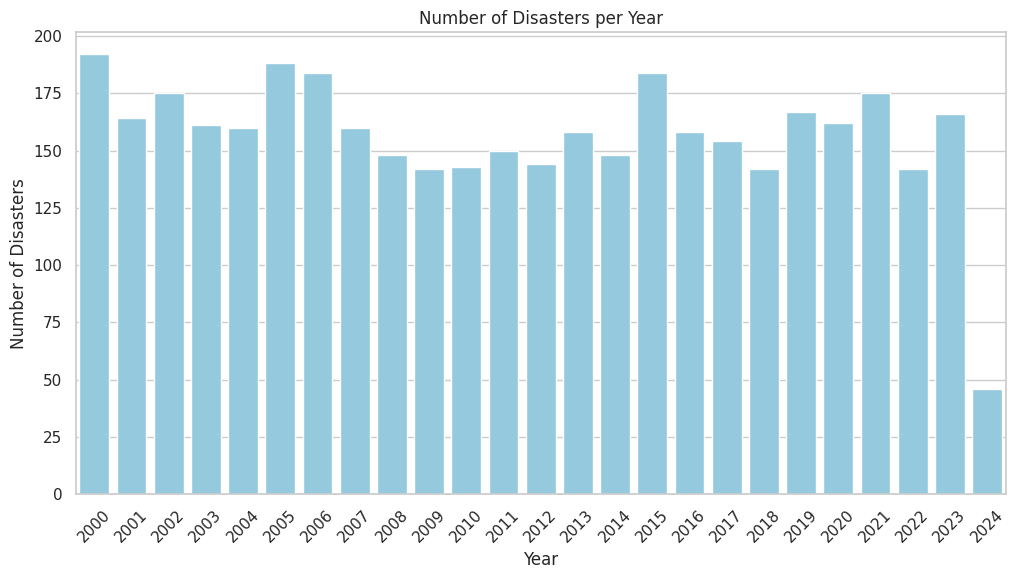

In [15]:
disasters_per_year = df['Start Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=disasters_per_year.index, y=disasters_per_year.values, color='skyblue')
plt.title('Number of Disasters per Year')
plt.xlabel('Year')
plt.ylabel('Number of Disasters')
plt.xticks(rotation=45)
plt.show()


<ipython-input-16-3f26ddcccea8>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=common_disasters.values, y=common_disasters.index, palette='viridis')


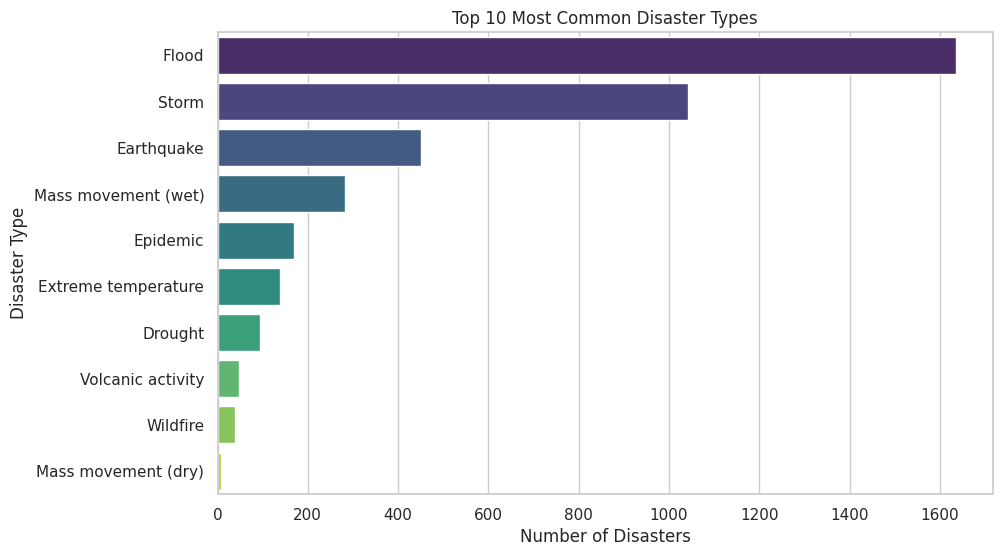

In [16]:
common_disasters = df['Disaster Type'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=common_disasters.values, y=common_disasters.index, palette='viridis')
plt.title('Top 10 Most Common Disaster Types')
plt.xlabel('Number of Disasters')
plt.ylabel('Disaster Type')
plt.show()

<ipython-input-17-bb96190da61f>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deaths_by_disaster.values, y=deaths_by_disaster.index, palette='rocket')


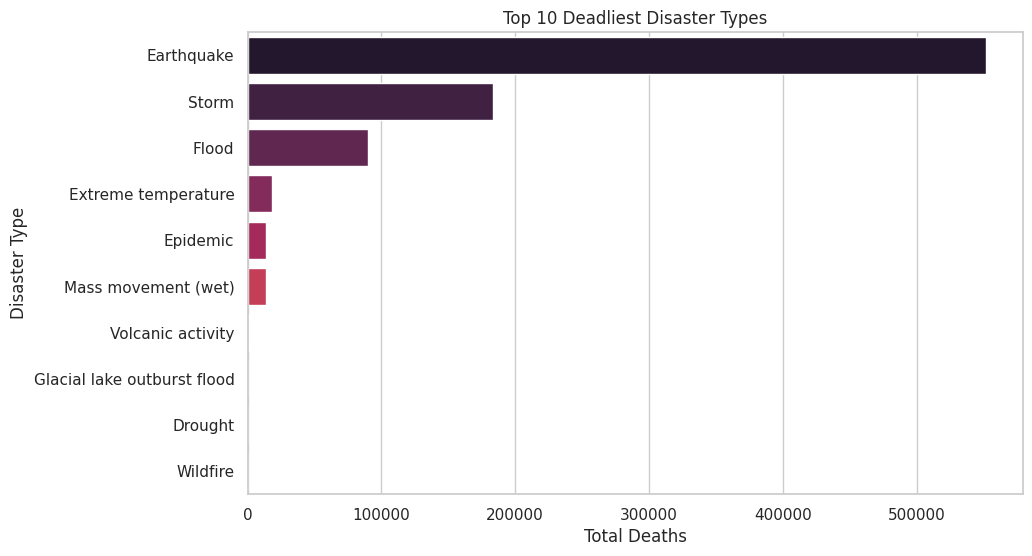

In [17]:
deaths_by_disaster = df.groupby('Disaster Type')['Total Deaths'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=deaths_by_disaster.values, y=deaths_by_disaster.index, palette='rocket')
plt.title('Top 10 Deadliest Disaster Types')
plt.xlabel('Total Deaths')
plt.ylabel('Disaster Type')
plt.show()

<ipython-input-18-056cfa2ec58c>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=damage_by_country.values, y=damage_by_country.index, palette='magma')


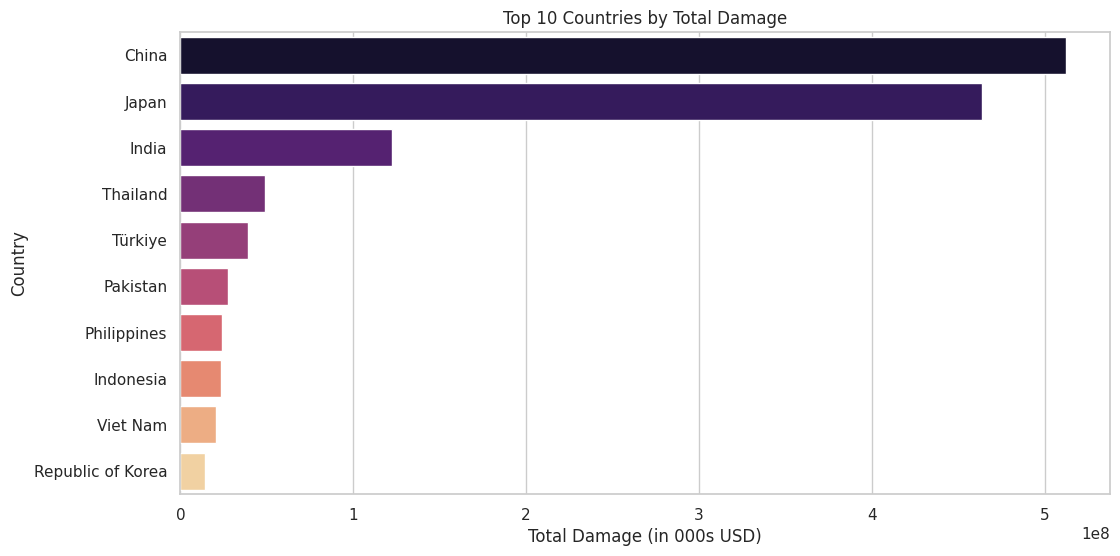

In [18]:
damage_col = "Total Damage ('000 US$)"

damage_by_country = df.groupby('Country')[damage_col].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=damage_by_country.values, y=damage_by_country.index, palette='magma')
plt.title('Top 10 Countries by Total Damage')
plt.xlabel('Total Damage (in 000s USD)')
plt.ylabel('Country')
plt.show()